# Unit I: Climate Change Module

## Reproducing the hockey stick, and checking whether we got it right

Our target is the result reported by [Mann et al (1998)](https://doi.org/10.1038/33859): that
recent warming stands outside the range of natural variability over the past several centuries.
You will rebuild that picture from current observations and ice-core records, in the style of
NASA's [vital signs](https://climate.nasa.gov/vital-signs).

A language model will write most of the parsing code. It is good at it, and it is also wrong in
ways that run cleanly and produce a plot. Your job is the question scientists have always had to
answer about code they did not write:

> **How do I know these numbers are right?**

Each part below gives you a data source and a question. It does not tell you what is wrong with
the data. Finding that out is the assignment.

## Rules of engagement

- **Plan mode only.** You review and approve the plan before any code runs.
- **Keep your prompts.** Record what you asked for. The prompt is part of your method.
- **Never report a number you have not checked.** Unverified or fabricated data is the one
  automatic-failure condition in this module, and it is no less serious because a model produced
  it.

Setup, GitHub authentication, and model configuration are on the
[course website](https://espm-157.carlboettiger.info/).

### Verification block

Every dataset gets these five questions answered, in your own words, **before** you plot it.
Each part below ends with one.

1. **Extent** — how many rows, what time range, and does that match the source documentation?
2. **Missing data** — how is it encoded, and did your parser catch it?
3. **Units** — what are they, and where in the source is that stated?
4. **Completeness** — the whole dataset, or one piece of it?
5. **Cross-check** — one value confirmed against an independent source.

---

# Part 1: The code you didn't write

Mauna Loa monthly CO2: <https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt>

Below is working code for that file. It runs and it produces a plausible plot.

In [20]:
import pandas as pd
from plotnine import *
import ibis
import matplotlib.pyplot as plt


In [2]:
columns = ['year', 'month', 'decimal_date', 'average', 'smooth', 'std_days', 'uncertainty', 'empty']
df = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt",
                  sep = '\s+',
                  comment = '#',
                  header = None,
                  names = columns
                  )
df

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_3264/60946832.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.


,year,month,decimal_date,average,smooth,std_days,uncertainty,empty
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26


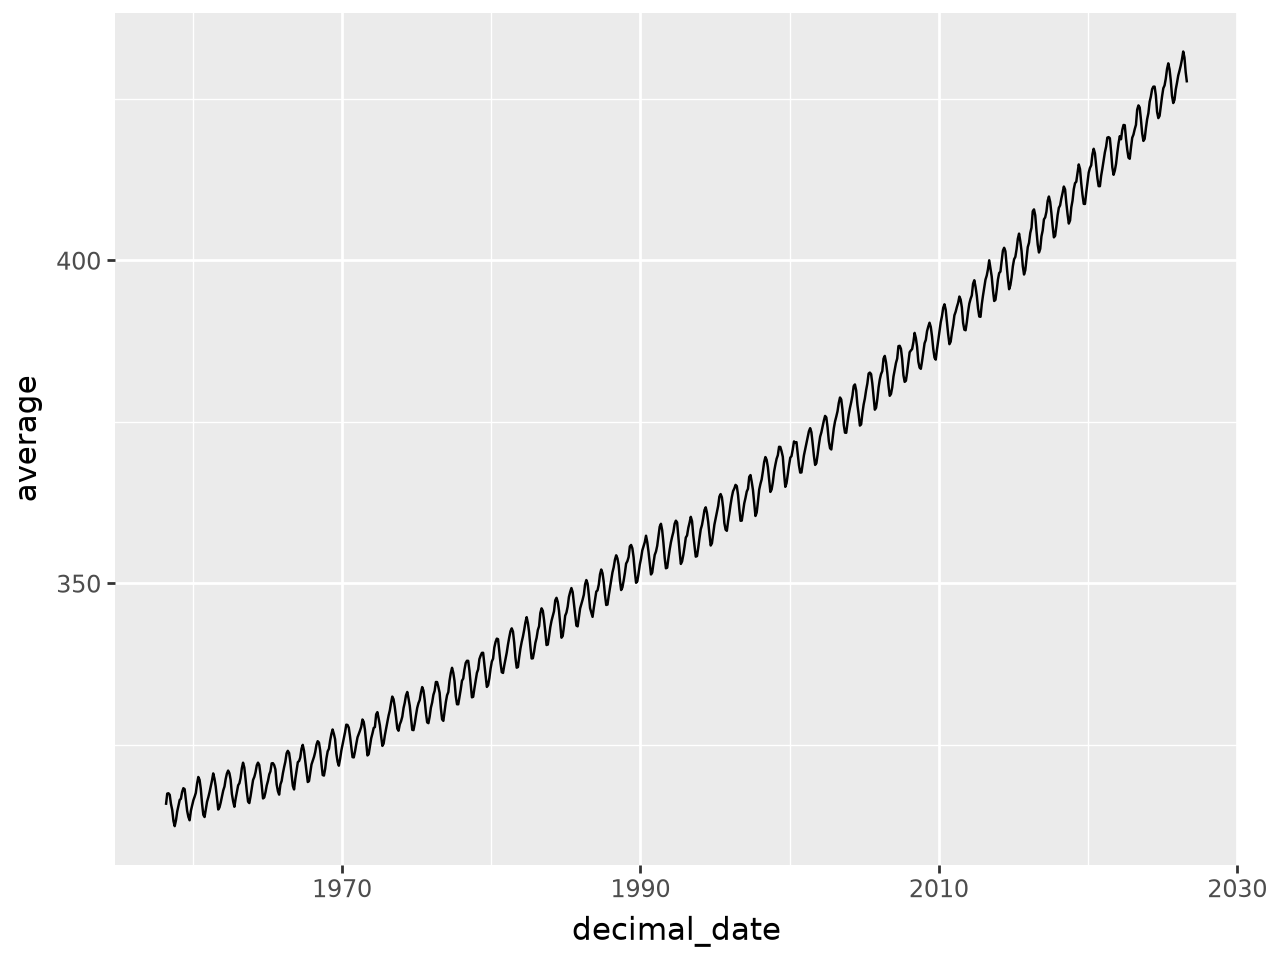

In [3]:
ggplot(df, aes(x="decimal_date", y="average")) + geom_line()

### Task 1.1: Read the source, not the code

That `columns` list was written by hand. Open the raw file and read its header block, then check
every name against what the header says the column holds. Report any that misstate it, and say
which of those would change a published figure if nobody noticed.

In [7]:
df.columns = ["year", "month", "decimal_date", "average", "deseasonalized", "ndays", "stdev", "uncertainty"]

**Your answer:**

The first four column names are correct but the last four are incorrect. Smooth is actually the deseasonalized monthly average, std_days is the number of observing days, uncertainty is the standard deviation, and empty is the uncertainty of the monthly mean. These mistakes do not affect the current graph for average CO2 because it only uses average, but they could make later graphs or error bars incorrect.



### Task 1.2: Missing values

How does this file encode a measurement that was not made? Verify it in the raw file, count the
affected rows per column, and say what a naive `mean()`, `min()`, or error bar would report if you
left them in. State what you did about it and why.

In [8]:
(df < 0).sum()

year                0
month               0
decimal_date        0
average             0
deseasonalized      0
ndays             195
stdev             196
uncertainty       194
dtype: int64

In [9]:
df[['ndays', 'stdev', 'uncertainty']].apply(
    lambda column: column[column < 0].value_counts()
)

,ndays,stdev,uncertainty
-9.99,NaN,196.0,NaN
-1.00,195.0,NaN,NaN
-0.99,NaN,NaN,194.0


In [10]:
missing_codes = {
    'ndays': -1,
    'stdev': -9.99,
    'uncertainty': -0.99
}

raw_df = df.copy()
df = df.replace(missing_codes)

df.isna().sum()

year              0
month             0
decimal_date      0
average           0
deseasonalized    0
ndays             0
stdev             0
uncertainty       0
dtype: int64

**Your answer:**

The raw file uses negative values to represent missing measurements. There are 195 missing values in ndays, 196 in stdev, and 194 in uncertainty. I replaced the negative values with NaN so they are ignored instead. This makes it so that the mean would not be too low due to the negatives, without this, the minimum would show the missing-value code, and error bars would be incorrect.

### Task 1.3: What the numeric columns cannot tell you

The header block contains prose notes as well as column definitions. Read them.

Does anything there change how you would plot or interpret this series? Show your evidence in the
data rather than asserting it, and say whether a model reading only the numeric columns would have
any way to know.

In [12]:
df.loc[
    (df["year"] == 2022) & (df["month"] == 12)
]

,year,month,decimal_date,average,deseasonalized,ndays,stdev,uncertainty
777,2022,12,2022.9583,418.99,419.79,24,0.57,0.22


**Your answer:**

The header has Mauna kea replacing Mauna Loa after an eruption on Nov 29, 2022 and this continues through until July 4, 2023. This is a change that would be easy to miss without reading the header block prose notes. 

### Task 1.4: Check whether a better door exists

Before you fix a parser, find out whether you need one. NOAA distributes this same monthly record
in more than one format: <https://gml.noaa.gov/ccgg/trends/data.html>

Load an alternative distribution. Which of the problems you found above does switching formats
solve, and which does it not?

In [14]:
csv_url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"

co2_csv = pd.read_csv(
    csv_url,
    comment="#"
)

co2_csv.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


**Your answer:**

The CSV format already has the column names that match the TXT values so we do not need to manually specify the seperator or fix parsing. 

In this CSV, the missing values are still represented by negative codes instead of missing values and scientific checks for things like the temporary station changes still need to be looked into before doing any analysis. 

### Task 1.5: The other library

Now try to load the original `.txt` with `ibis` instead of `pandas`. Report what happens.

Explain the result in terms of the *file*, not the library. What does it do to a rule like "always
use `ibis`"?

In [16]:
txt_url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"

con = ibis.duckdb.connect()
co2_ibis = con.read_csv(txt_url, table_name="co2_txt")

co2_ibis.schema()
co2_ibis.limit(5).execute()

,# --------------------------------------------------------------------
0,# USE OF NOAA GML DATA
1,#
2,# These data are made freely available to the ...
3,# community in the belief that their wide diss...
4,# greater understanding and new scientific ins...


**Your answer:**

Ibis was not able to parse the orginal text file correctly, it loaded the file as one text column which is incorrect. Since the text file has comments and header lines, it needs to be parsed with white spacing so this shows that using a rule like always use ibis is not always the best advice. 

### 🔍 Verification block 1

1. Extent: The dataset has 822 monthly rows that go from March 1958 to August 2026.
2. Missing data: Missing values are shown as negatives, such as -1 for ndays. 
3. Units: CO2 is measured in ppm
4. Completeness: This is the full monthly record from NOAA,
5. Cross-check: I checked a row in Decemeber 2022 from the alternative csv which had 418.99 pm,  this agrees with the text file.

### Plot

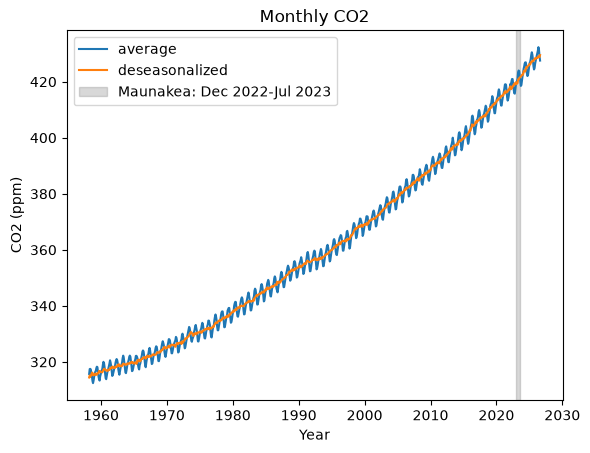

In [24]:
df.plot(
    x="decimal_date",
    y=["average", "deseasonalized"],
    ylabel="CO2 (ppm)",
    title="Monthly CO2"
)

plt.axvspan(
    2022.9583,
    2023.5417,
    color="gray",
    alpha=0.3,
    label="Maunakea: Dec 2022-Jul 2023"
)

plt.xlabel("Year")
plt.legend()
plt.show()

---

# Part 2: Arctic sea ice

National Snow and Ice Data Center, sea ice index G02135:

- Documentation: <https://nsidc.org/data/G02135>
- Data directory: <https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/>

### Task 2.1: Ask first, look second

Before opening that directory yourself, ask your model to load Arctic sea ice extent and plot the
trend. Let it produce a plan.

**Record the prompt you used:**

```
[Load the Arctic sea ice extent record from the NSIDC G02135 monthly data directory and plot sea ice extent over time. Before writing code, make a plan that identifies the correct file, explains the file format, checks the units, and describes how missing values and dates will be handled.]
```

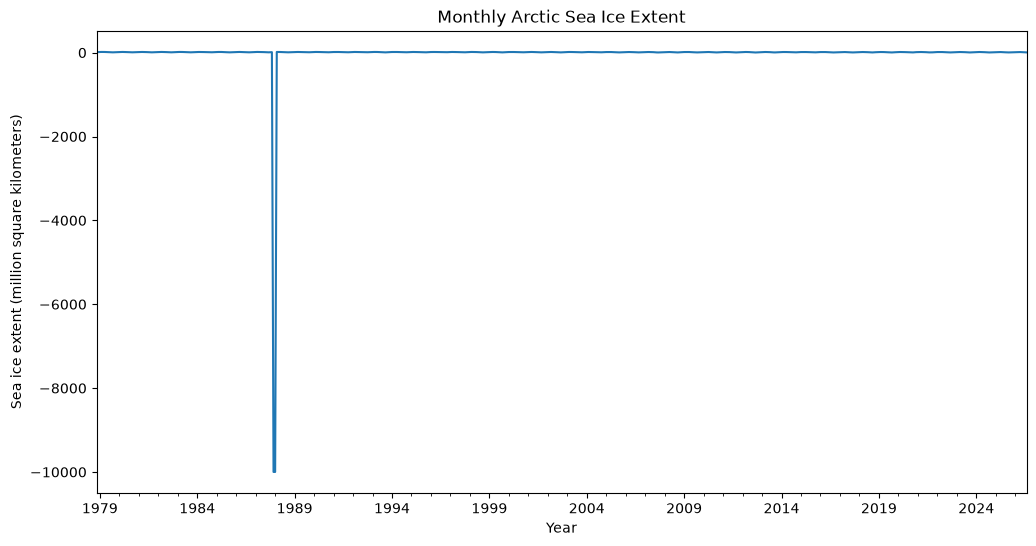

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

base_url = "https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/"

files = [
    f"N_{month:02d}_extent_v4.0.csv"
    for month in range(1, 13)
]

sea_ice = pd.concat(
    [
        pd.read_csv(base_url + filename)
        for filename in files
    ],
    ignore_index=True
)

sea_ice.columns = sea_ice.columns.str.strip()

sea_ice["date"] = pd.to_datetime(
    dict(
        year=sea_ice["year"],
        month=sea_ice["mo"],
        day=1
    )
)

sea_ice = sea_ice.sort_values("date")

sea_ice.plot(
    x="date",
    y="extent",
    figsize=(12, 6),
    title="Monthly Arctic Sea Ice Extent",
    xlabel="Year",
    ylabel="Sea ice extent (million square kilometers)",
    legend=False
)

plt.show()

### Task 2.2: What did it actually load?

Now open the data directory and look at what is there.

Check the URL the model's code used against the directory listing *before* you run anything. Did
it point at a file that exists? If it ran, how much of the record does the plot actually show, and
is the title honest? If it failed, would you have predicted that failure from reading the code?

A model that has never seen this directory still has to produce a filename. Note where it got one.

**Your answer:**

The directory contained 12 files, one for each month. These contained 574 monthly records from 1979 to 2025. The issue with this plot was that it shows a drop of 10,000 million square km around 1987, this was due to the dataset using -9999 in order to represent missing values and our code plotted this as a real value which is why we see the out of place and sudden drop spike. The title seems to be honest since this data does show monhtly arctic sea ice extent and the main failure is the misleading -9999 value that was used to replace missing values. 

### Task 2.3: Build the complete record

Load the full dataset and plot sea ice extent over time.

Then make a scientific decision and defend it: the September minimum is the standard index for
Arctic sea ice loss, and it is not the same thing as the annual mean. Which does your analysis
report, and why is that right for the question you are asking?

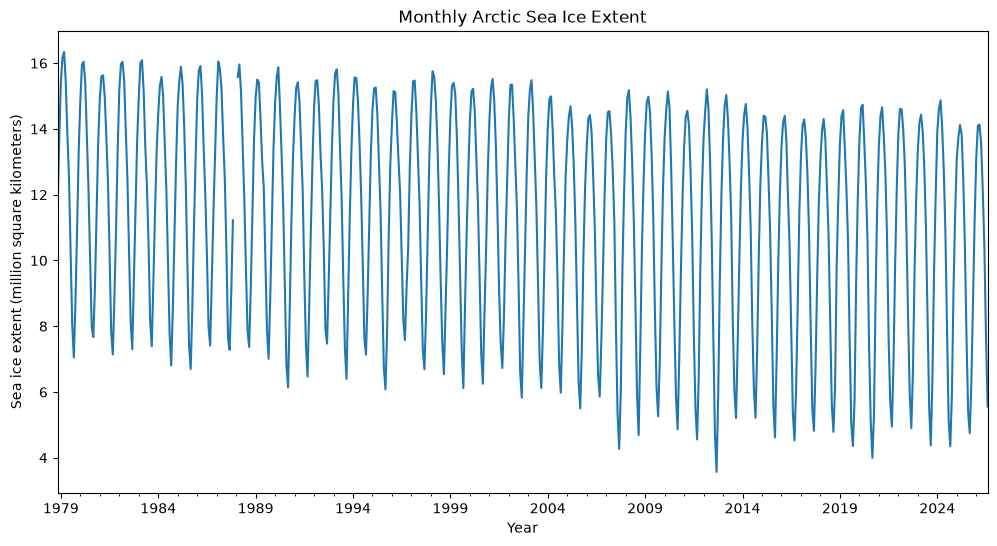

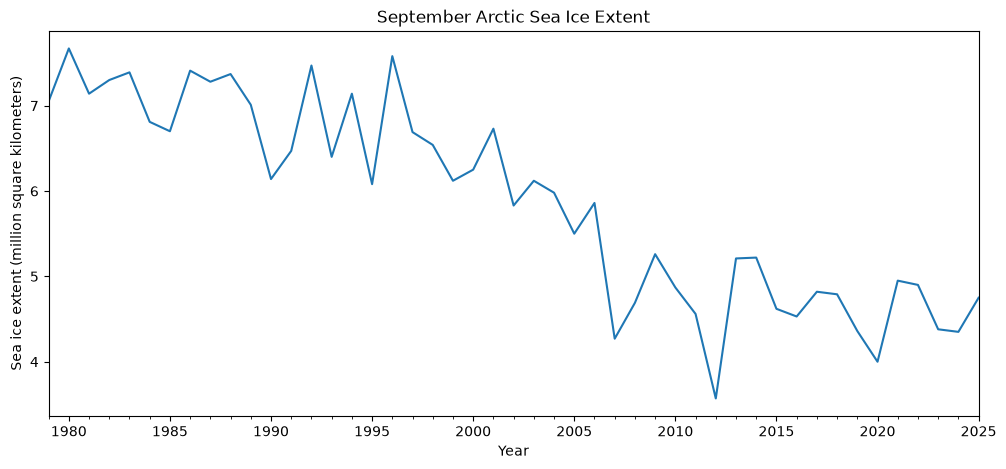

In [29]:
import numpy as np

sea_ice["extent"] = pd.to_numeric(
    sea_ice["extent"],
    errors="coerce"
).replace(-9999, np.nan)

sea_ice.plot(
    x="date",
    y="extent",
    figsize=(12, 6),
    title="Monthly Arctic Sea Ice Extent",
    xlabel="Year",
    ylabel="Sea ice extent (million square kilometers)",
    legend=False
)

plt.show()

september = sea_ice[sea_ice["mo"] == 9]

september.plot(
    x="date",
    y="extent",
    figsize=(12, 5),
    title="September Arctic Sea Ice Extent",
    xlabel="Year",
    ylabel="Sea ice extent (million square kilometers)",
    legend=False
)

plt.show()

**Your answer:**
My analysis reports the September sea ice extent, this is the right decision since September is the standard measure of arctic sea ice loss since it represents the summer minimum where ice cover is at a minimum. This allows us to have a plot that shows the long term decline in a comparitive way year over year. 


### 🔍 Verification block 2

1. Extent: The dataset contains 574 monthly records.
2. Missing data: Missing values were written as -9999, this is shown in 1987.
3. Units:Sea ice extent is measured in million square km.
4. Completeness: All Northern Hemisphere monthly files
5. Cross-check: I checked the December 2022 value against the december monthly file, both files reported an extent of 11.89 million square km which shows that the underlying data is the same. 

---

# Part 6: Reflection

1. **Failure inventory.** List every case where the model produced code that ran without error but
   was wrong. What was wrong, and what tipped you off?
2. **Detection.** Which of those would you have caught from the plot alone? Which required going
   back to the source documentation?
3. **Division of labor.** What did you contribute that the model did not? If the answer for some
   task is "nothing", say so.
4. **Plan mode.** Where did approving the plan catch something? Where was it just friction?
5. **Tool choice.** You have now seen the same task done two ways, and data read locally versus
   streamed. What decides which is right, and who makes that decision?

**Your reflection:**

1. The models main issue was when it treated negative missing value codes as real data, such as when it assumed -9999 was a real value instead of a placeholder that the dataset used to represent missing data. This was easily noticed by creating visualizations or looking at the population of the data to see outliers. 
2. This main issue of negative values as real data was able to be caught by the plot alone. This was able to be seen by the large spikes in the visualization and then by looking more deeply into the data source to see the reason.
3. I contributed by checking source files, verifying column meanings, and identifying missing value codes such as the -9999 case. 
4. Using plan mode was useful since it allowed me to understand a little of the thought process of the LLM instead of blindly trusting its output, I would say that it was not just friction and it actually provided useful information that caught issues that would have occured if I had not used plan mode. 
5. The correct tool always depends on the file structure and the context of the scientific question. It makes sense to use pandas for smaller tables but using DuckDB for larger tables like transactions or etc mattters for effiency. It should be up to the person to make that decision and not rely on a model to choose decisions like these. 

---

## Submission

- [ ] Notebook runs top to bottom without errors
- [ ] All three verification blocks completed
- [ ] Prompts recorded where asked (Tasks 2.1, 3.1)
- [ ] Memory and timing table filled in (Task 3.3)
- [ ] Stressor selection defended (Task 4.3) and reconciliation quantified (Task 4.4)
- [ ] Hockey stick figure with the modern record in geological context (Task 5.2)
- [ ] Reflection complete (Part 6)
- [ ] README updated with team members, badge, and description
- [ ] Repository passes its GitHub Actions check

See [rubric.md](rubric.md) for scoring.